# Taller B5-T1 · Generación de datos financieros sintéticos
## Notebook 04 — La malla real × sintético

**Esta es la pregunta del taller.** Los notebooks anteriores construyeron las piezas: el
dataset con splits purgados (01), la arquitectura downstream congelada y los baselines
clásicos (02), y seis generadores auditados contra los hechos estilizados (03). Aquí se
responde: **¿cuántos datos sintéticos ayudan, en qué régimen de escasez de datos reales, y
qué generador los produce mejor?**

### El experimento

Para cada combinación (N_real, generador, ratio, semilla):

1. Se submuestrean `N_real` ventanas del train.
2. El generador se **reentrena con esas `N_real` ventanas y solo esas**.
3. Se generan `N_synth = ratio × N_real` ventanas sintéticas.
4. Se entrena la arquitectura **congelada** del notebook 02 sobre la mezcla.
5. Se evalúa en el **test real**, intocado y siempre el mismo.

### Las cuatro reglas que hacen esto interpretable

| Regla | Por qué |
|---|---|
| **El generador se reentrena en cada celda** | Ajustarlo con las 102k ventanas y luego *simular* escasez sería fuga: los sintéticos llevarían información de datos que el escenario declara no tener, y la curva saldría optimista. |
| **Submuestreo por fechas, no por filas** | En una fecha dada todas las ventanas del panel cuentan la misma historia de mercado. Un muestreo de filas daría un N nominal muy superior al efectivo. |
| **Validación siempre real** | Si el early-stopping mirase datos sintéticos, optimizaríamos la distribución equivocada. |
| **Arquitectura e hiperparámetros congelados** | Si una celda rinde distinto, la única explicación posible son los datos. |

> **Métrica principal: `delta_r2`** — la ganancia de R² en test de cada celda frente a la
> celda de *solo real* con el mismo N. Responde literalmente al enunciado: para el mismo
> presupuesto de datos reales, ¿cuánto añade el sintético? El umbral de relevancia lo fijó
> el notebook 02: **±0,006**, la dispersión entre semillas del modelo con datos reales.
> Cualquier efecto por debajo de eso es ruido de optimización, no señal.

## 0 · Setup y configuración de la malla

**Tres tamaños de malla.** `REDUCIDA` valida el pipeline y cubre el régimen de escasez;
`COMPLETA` añade el extremo de datos abundantes; `RATIOS_FINOS` mantiene los mismos tres
niveles de escasez y **refina el eje del presupuesto sintético por debajo de 1×**.

El presupuesto sintético se declara siempre como **multiplicador** de los reales de la
celda (`n_synth = ratio × n_real`), nunca como un conteo absoluto: así una fila con
`ratio=3` significa lo mismo con N=250 que con N=3.000, que es lo que permite comparar
regímenes de escasez entre sí. (La lectura complementaria —presupuesto sintético fijo
mientras varían los reales— es la §2.5, y necesita el otro diseño precisamente porque
un multiplicador no puede mantenerse constante a lo largo de ese eje.)

**Por qué 0,25× · 0,5× · 0,75× y no solo múltiplos enteros.** Con la malla `[0, 1, 3]` el
primer punto medido ya duplica el conjunto de entrenamiento: entre "nada de sintético" y
"tanto sintético como real" no hay ninguna observación. Si el efecto del dato sintético
cambia de signo ahí —y es donde más razones hay para esperarlo, porque es donde la mezcla
pasa de estar dominada por el dato real a no estarlo— la malla anterior no puede verlo.
Los tres ratios fraccionarios miden precisamente ese tramo: 0,25× añade una ventana
sintética por cada cuatro reales, una dosis que un generador mediocre todavía no puede
arruinar.

Los ratios 10×, 20× y 30× quedan **fuera a propósito**: multiplicaban el coste por cuatro
(153 min frente a 37) y su única función era buscar el punto de giro por arriba, que es
una pregunta distinta y se puede añadir después sin rehacer nada — la malla es reanudable
y la clave de reanudación incluye el ratio.

**Submuestreo de la validación.** La validación real tiene 17.146 ventanas y se evalúa en
cada época de cada celda: a N pequeño ese coste fijo **domina el tiempo total** de la malla
(medido: ~45 s por celda con N=300). Como su único papel es elegir la época de la que se
conservan los pesos, 5.000 ventanas reales bastan de sobra y el coste por celda cae unas
tres veces. Es una decisión de eficiencia que no toca ninguna comparación: la validación es
idéntica en todas las celdas.

In [1]:
import sys, json, time
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src.config import Config, set_global_seed
from src.eda import PALETTE, _style
from src.malla import (plan_de_malla, ejecutar_malla, resumir, delta_vs_solo_real,
                       delta_pareado, umbral_ruido_por_n, SOLO_REAL, GENERADORES_ACTIVOS)
from src.training import get_device

cfg = Config()
set_global_seed(cfg.seed)
device = get_device()
print("Device:", device)

# ---- Tamaño de la malla -------------------------------------------------
MALLA = "RATIOS_FINOS"      # "REDUCIDA", "RATIOS_FINOS" o "COMPLETA"

CONFIG_MALLA = {
    "REDUCIDA": dict(n_reales=[250, 1000, 3000], ratios=[0, 1, 3], seeds=[0, 1, 2]),
    # Mismos niveles de escasez, eje de ratio con resolución fina por debajo de 1x:
    # es el tramo que la malla REDUCIDA se saltaba entero.
    "RATIOS_FINOS": dict(n_reales=[250, 1000, 3000],
                         ratios=[0, 0.25, 0.5, 0.75, 1, 3, 5], seeds=[0, 1, 2]),
    "COMPLETA": dict(n_reales=[250, 1000, 3000, 10000], ratios=[0, 1, 3, 10], seeds=[0, 1, 2]),
}[MALLA]

GENERADORES = list(GENERADORES_ACTIVOS)
N_VAL = 5000                # submuestra de validación (real) — ver nota arriba
RUTA_CSV = cfg.out_dir / f"malla_{MALLA.lower()}.csv"

print(f"Malla {MALLA}: {CONFIG_MALLA}")
print(f"Resultados -> {RUTA_CSV}")

Device: cuda
Malla RATIOS_FINOS: {'n_reales': [250, 1000, 3000], 'ratios': [0, 0.25, 0.5, 0.75, 1, 3, 5], 'seeds': [0, 1, 2]}
Resultados -> C:\Users\diego\MIAX\15-generacion-datos-sinteticos\B5T1\Taller-M5T1---Datos-Sinteticos\.worktrees\diffusion-ts-research\data\processed\malla_ratios_finos.csv


In [2]:
# ---- Datos: todo lo que la malla puede tocar ----------------------------
d   = np.load(cfg.out_dir / "windows_dataset.npz")
std = json.load(open(cfg.out_dir / "standardizer.json"))
ref = json.load(open(cfg.out_dir / "downstream_reference.json"))   # arquitectura CONGELADA
meta = pd.read_parquet(cfg.out_dir / "windows_meta.parquet")
meta_train = meta[meta.split == "train"].reset_index(drop=True)

S = lambda a, m, s: ((a - std[m]) / std[s]).astype(np.float32)

# validación real submuestreada, fija para TODAS las celdas
rng_val = np.random.default_rng(cfg.seed)
iv = rng_val.choice(len(d["X_val"]), min(N_VAL, len(d["X_val"])), replace=False)

CONTEXTO = dict(
    Xs_train=S(d["X_train"], "x_mu", "x_sd"), ys_train=S(d["y_train"], "y_mu", "y_sd"),
    meta_train=meta_train,
    Xs_val=S(d["X_val"], "x_mu", "x_sd")[iv], ys_val=S(d["y_val"], "y_mu", "y_sd")[iv],
    Xs_test=S(d["X_test"], "x_mu", "x_sd"), y_test_fisico=d["y_test"],
    std=std, ref=ref, device=device,
)

print(f"Arquitectura congelada: {ref['arch']} {ref['arch_kwargs']}")
print(f"Referencia con datos reales completos: R² test = "
      f"{np.mean([v['test_r2'] for v in ref['metricas_seeds'].values()]):.4f}")
print(f"train {meta_train.shape[0]:,} ventanas / {meta_train.date_t.nunique():,} fechas | "
      f"val {len(iv):,} (submuestra) | test {len(d['X_test']):,}")

Arquitectura congelada: gru {'hidden': 72, 'layers': 3, 'fc': 72}
Referencia con datos reales completos: R² test = 0.4716
train 102,406 ventanas / 2,372 fechas | val 5,000 (submuestra) | test 24,613


## 1 · Ejecución de la malla

El plan se ordena de **coste creciente**: si la ejecución se interrumpe, lo ya calculado es
el régimen de escasez, que es el que más importa. Cada celda se escribe al CSV en cuanto
termina, así que **relanzar esta celda reanuda donde se quedó** sin recalcular nada.

In [3]:
plan = plan_de_malla(generadores=GENERADORES, **CONFIG_MALLA)
print(f"{len(plan)} celdas en el plan "
      f"({len(CONFIG_MALLA['n_reales'])} niveles de N × "
      f"{len(CONFIG_MALLA['ratios'])} ratios × {len(GENERADORES)} generadores × "
      f"{len(CONFIG_MALLA['seeds'])} semillas)")

333 celdas en el plan (3 niveles de N × 7 ratios × 6 generadores × 3 semillas)


In [4]:
t0 = time.time()
df = ejecutar_malla(plan, RUTA_CSV, **CONTEXTO)
print(f"\nMalla terminada en {(time.time() - t0)/60:.1f} min | {len(df)} celdas en el CSV")

Malla: 333 celdas | ya hechas: 333 | pendientes: 0

Malla terminada en 0.0 min | 333 celdas en el CSV


## 2 · Resultados

### 2.1 Tabla resumen

In [5]:
resumen = resumir(df)
delta = delta_vs_solo_real(resumen)

# referencia de cada N: cuánto rinde el modelo con SOLO datos reales
print("Referencia — solo datos reales:")
display(resumen[resumen.generador == SOLO_REAL][["n_real", "test_r2_media", "test_r2_sd"]].round(4))

# tabla principal: ganancia frente a esa referencia
tabla = delta.pivot_table(index=["n_real", "generador"], columns="ratio", values="delta_r2")
tabla.round(4)

Referencia — solo datos reales:

,n_real,test_r2_media,test_r2_sd
24,250,0.1514,0.1149
61,1000,0.1994,0.1614
98,3000,0.3380,0.0223


ratio                    0.248   0.250   0.500   0.750   0.752   1.000  \
n_real generador                                                         
250    block_bootstrap -0.0278     NaN -0.0367     NaN -0.0403 -0.0435   
       diffusion_ts        NaN -0.0146 -0.0814 -0.0738     NaN -0.0583   
       gaussiana       -0.0131     NaN -0.0187     NaN -0.0512 -0.0609   
       jitter          -0.0062     NaN  0.0096     NaN  0.0066  0.0006   
       realnvp         -0.0267     NaN -0.0228     NaN -0.0280 -0.0198   
       vae             -0.0085     NaN  0.0053     NaN -0.0290 -0.0328   
1000   block_bootstrap     NaN  0.1024  0.0934  0.0644     NaN  0.0611   
       diffusion_ts        NaN  0.0989  0.1028  0.0946     NaN  0.1051   
       gaussiana           NaN  0.0616  0.0639  0.0517     NaN  0.0344   
       jitter              NaN  0.0986  0.1149  0.1156     NaN  0.1174   
       realnvp             NaN  0.1069  0.1059  0.1059     NaN  0.1043   
       vae                 NaN  0.0953  0.0915  0.0636     NaN  0.0641   
3000   block_bootstrap     NaN  0.0143  0.0275  0.0343     NaN  0.0173   
       diffusion_ts        NaN  0.0136  0.0257  0.0385     NaN  0.0444   
       gaussiana           NaN -0.0388 -0.0687 -0.0849     NaN -0.1012   
       jitter              NaN  0.0199  0.0317  0.0312     NaN  0.0323   
       realnvp             NaN  0.0186  0.0379  0.0330     NaN  0.0515   
       vae                 NaN -0.0153 -0.0238 -0.0232     NaN -0.0298   

ratio                    3.000   5.000  
n_real generador                        
250    block_bootstrap -0.0507  0.0191  
       diffusion_ts    -0.1147  0.0765  
       gaussiana       -0.1081 -0.0109  
       jitter          -0.0271  0.0764  
       realnvp         -0.0689  0.0209  
       vae             -0.1519  0.0187  
1000   block_bootstrap  0.0967  0.1025  
       diffusion_ts     0.1389  0.1582  
       gaussiana        0.0026 -0.0454  
       jitter           0.1648  0.1746  
       realnvp          0.1468  0.1307  
       vae              0.0655  0.0628  
3000   block_bootstrap  0.0190  0.0189  
       diffusion_ts     0.0580  0.0629  
       gaussiana       -0.1524 -0.1803  
       jitter           0.0523  0.0495  
       realnvp          0.0773  0.0814  
       vae             -0.0422 -0.0658

### 2.1.b Análisis pareado: la comparación que sí es válida

**Corrección metodológica importante.** El notebook 02 fijó un umbral de relevancia de
±0,006 midiendo la dispersión entre semillas del modelo entrenado con las **102.406
ventanas reales completas**. Ese umbral **no vale aquí**: en régimen de escasez la
dispersión entre semillas es de 5 a 11 veces mayor, porque cada semilla sortea un
submuestreo distinto de datos reales y eso mueve el R² mucho más que cualquier efecto del
sintético.

La solución no es subir el umbral, sino **parear**. La semilla determina qué ventanas
reales "existen" en el escenario, así que comparamos cada celda contra la celda de
solo-real **de su misma semilla**: la varianza del submuestreo se cancela y queda solo el
efecto del dato sintético. Con 3 semillas exigimos |t| ≥ 2,5 para hablar de efecto; por
debajo, la celda se declara **no concluyente** en lugar de inventar una conclusión.

In [6]:
print("Dispersión entre semillas del modelo SOLO REAL (el umbral honesto en cada régimen):")
u = umbral_ruido_por_n(df)
display(pd.DataFrame({"sd_entre_semillas": u.round(4),
                      "veces el umbral del nb02 (0,006)": (u / 0.006).round(0)}))

par = delta_pareado(df)
print("\nΔ R² pareado por semilla — solo las celdas con veredicto:")
concluyentes = par[par.veredicto != "no concluyente"].sort_values("t")
display(concluyentes[["n_real", "generador", "ratio", "delta_medio", "ee", "t", "veredicto"]].round(4))
print(f"\n{len(par)} celdas: {(par.veredicto=='mejora').sum()} mejoran, "
      f"{(par.veredicto=='empeora').sum()} empeoran, "
      f"{(par.veredicto=='no concluyente').sum()} no concluyentes")

Dispersión entre semillas del modelo SOLO REAL (el umbral honesto en cada régimen):


,sd_entre_semillas,"veces el umbral del nb02 (0,006)"
n_real,,
250,0.1149,19.0
1000,0.1614,27.0
3000,0.0223,4.0



Δ R² pareado por semilla — solo las celdas con veredicto:


,n_real,generador,ratio,delta_medio,ee,t,veredicto
89,3000,gaussiana,5.000,-0.1803,0.0153,-11.7609,empeora
88,3000,gaussiana,3.000,-0.1524,0.0290,-5.2514,empeora
103,3000,vae,0.500,-0.0238,0.0070,-3.4189,empeora
107,3000,vae,5.000,-0.0658,0.0198,-3.3270,empeora
14,250,gaussiana,0.752,-0.0512,0.0185,-2.7726,empeora
32,250,vae,0.752,-0.0290,0.0109,-2.6541,empeora
1,250,block_bootstrap,0.500,-0.0367,0.0146,-2.5232,empeora
94,3000,jitter,3.000,0.0523,0.0201,2.6049,mejora
23,250,jitter,5.000,0.0764,0.0287,2.6591,mejora
98,3000,realnvp,0.750,0.0330,0.0119,2.7674,mejora



108 celdas: 21 mejoran, 7 empeoran, 80 no concluyentes


### 2.2 La figura del taller: ganancia frente a proporción de sintéticos

Un panel por nivel de escasez. La banda gris es el **umbral de relevancia** (±0,006, la
dispersión entre semillas del notebook 02): cualquier curva dentro de esa banda es ruido,
no efecto.

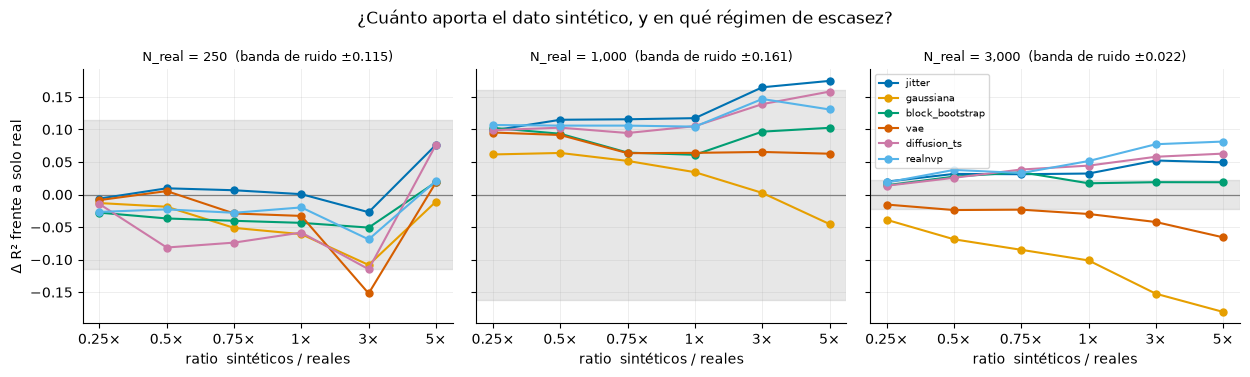

In [7]:
n_paneles = len(CONFIG_MALLA["n_reales"])
fig, axes = plt.subplots(1, n_paneles, figsize=(4.2 * n_paneles, 3.8), sharey=True)
axes = np.atleast_1d(axes)
colores = [PALETTE[c] for c in ("blue", "orange", "green", "vermillion", "purple", "sky")]
# La banda es la dispersión entre semillas del solo-real EN CADA N (ver §2.1.b),
# no el ±0,006 del notebook 02, que solo vale con las 102k ventanas completas.
UMBRAL_POR_N = umbral_ruido_por_n(df)
#: Los ratios con sintético, en el orden del eje (el 0 es la referencia solo-real,
#: que se dibuja como banda y línea, no como punto de las series).
RATIOS_EJE = [r for r in sorted(CONFIG_MALLA["ratios"]) if r > 0]


def pos_ratio(r: float) -> int:
    """Posición en el eje del nominal más cercano al ratio REALIZADO.

    El CSV guarda el ratio que de verdad se ejecutó, no el que se pidió:
    `ejecutar_celda` lo recalcula como n_synth / n_real, y n_synth es un
    entero redondeado. Con N=250 y ratio 0,25 salen round(62,5) = 62 ventanas,
    es decir 0,248; con 0,75 salen 188, es decir 0,752. Buscar el nominal por
    igualdad de floats falla ahí. Se asigna al más próximo, que es inequívoco
    porque los niveles distan mucho más entre sí que el error de redondeo.
    """
    return int(np.argmin([abs(r - x) for x in RATIOS_EJE]))

for ax, n in zip(axes, CONFIG_MALLA["n_reales"]):
    sub = delta[delta.n_real == n]
    u = UMBRAL_POR_N[n]
    ax.axhspan(-u, u, color=PALETTE["grey"], alpha=0.18, zorder=0)
    ax.axhline(0, color=PALETTE["grey"], lw=0.9)
    for col, g in zip(colores, GENERADORES):
        s = sub[sub.generador == g].sort_values("ratio")
        if len(s):
            # Posiciones equiespaciadas, no el valor del ratio: en eje lineal los
            # ratios bajos (1, 3, 5) se aplastarían contra el margen izquierdo, y es
            # justo ahí donde se decide si la curva gira. Un eje log tampoco vale:
            # el 0 del solo-real no cabe en él.
            xp = [pos_ratio(r) for r in s.ratio]
            ax.plot(xp, s.delta_r2, "o-", color=col, lw=1.5, ms=5, label=g)
    ax.set_xticks(range(len(RATIOS_EJE)))
    ax.set_xticklabels([f"{r:g}×" for r in RATIOS_EJE])
    ax.set_title(f"N_real = {n:,}  (banda de ruido ±{u:.3f})", fontsize=9)
    ax.set_xlabel("ratio  sintéticos / reales")
    _style(ax)
axes[0].set_ylabel("Δ R² frente a solo real")
axes[-1].legend(fontsize=7, loc="best")
fig.suptitle("¿Cuánto aporta el dato sintético, y en qué régimen de escasez?")
fig.tight_layout()
fig.savefig(cfg.fig_dir / "14_delta_r2_por_escasez.png", dpi=120, bbox_inches="tight")

### 2.3 Curvas de aprendizaje: R² frente a datos reales disponibles

La lectura complementaria — y la que reproduce la forma de la gráfica que el profesor
mostró en clase. La línea negra discontinua es el techo: el modelo entrenado con las
**102.406 ventanas reales completas** (notebook 02).

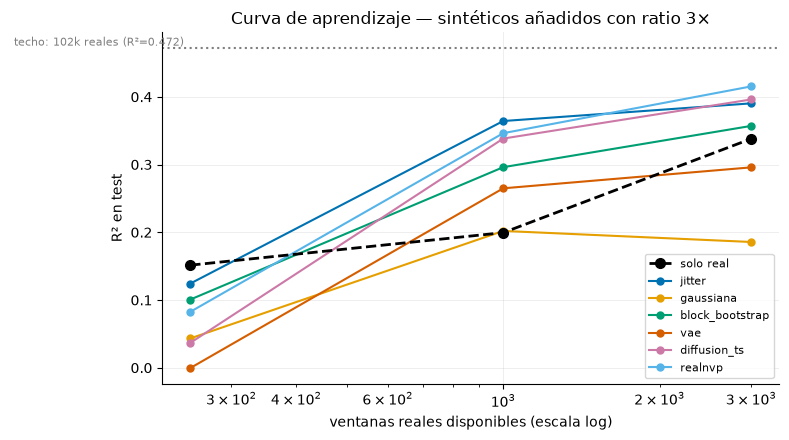

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
techo = np.mean([v["test_r2"] for v in ref["metricas_seeds"].values()])

base = resumen[resumen.generador == SOLO_REAL].sort_values("n_real")
ax.plot(base.n_real, base.test_r2_media, "o--", color="black", lw=2, ms=7,
        label="solo real", zorder=5)

RATIO_FOCO = 3 if 3 in CONFIG_MALLA["ratios"] else max(CONFIG_MALLA["ratios"])
for col, g in zip(colores, GENERADORES):
    s = resumen[(resumen.generador == g) & (resumen.ratio == RATIO_FOCO)].sort_values("n_real")
    if len(s):
        ax.plot(s.n_real, s.test_r2_media, "o-", color=col, lw=1.5, ms=5, label=g)

ax.axhline(techo, color=PALETTE["grey"], ls=":", lw=1.5)
ax.text(ax.get_xlim()[0], techo, f" techo: 102k reales (R²={techo:.3f})",
        va="bottom", fontsize=8, color=PALETTE["grey"])
ax.set_xscale("log")
ax.set_xlabel("ventanas reales disponibles (escala log)")
ax.set_ylabel("R² en test")
ax.set_title(f"Curva de aprendizaje — sintéticos añadidos con ratio {RATIO_FOCO}×")
ax.legend(fontsize=8)
_style(ax)
fig.tight_layout()
fig.savefig(cfg.fig_dir / "15_curva_aprendizaje.png", dpi=120, bbox_inches="tight")

### 2.4 ¿Predice la auditoría del notebook 03 el efecto downstream?

La pregunta que cierra el círculo del taller. En el notebook 03 medimos cada generador **sin
mirar el modelo downstream**, en dos ejes: **fidelidad** (discriminative AUC, curtosis,
clustering, distancias marginales y de dependencia) y **utilidad** (el ratio TSTR/TRTR, que
entrena un modelo *solo* con datos sintéticos). Si esas métricas anticipan la ganancia real
de la malla, se puede elegir generador midiendo el sintético, sin barrer una malla entera.

> **Los números se leen del CSV que el notebook 03 persiste**, no de una tabla copiada a
> mano. Es una precaución con historia: la malla **reentrena** cada generador en cada celda,
> así que si los hiperparámetros del 03 y los de `malla.construir_generador` se desviaran, una
> tabla escrita a mano seguiría mostrando las cifras viejas y la correlación de esta sección
> compararía dos cosas distintas sin avisar.

Se cruza contra el **delta pareado** (§2.1.b) y se calcula la correlación de rangos de
Spearman por nivel de escasez, porque el resultado depende críticamente del régimen. Ojo con
los **signos**: en `discriminative_auc`, las distancias (`w1_*`, `err_*`) menos es mejor, así
que una correlación **negativa** significa que la métrica predice bien; en `curtosis_x`,
`acf_abs_lag1` y `ratio_tstr_trtr` es al revés.

In [9]:
# Auditoría del notebook 03, leída del CSV que ese notebook persiste en su §6.
RUTA_AUD, RUTA_TSTR = cfg.out_dir / "auditoria_nb03.csv", cfg.out_dir / "tstr_nb03_resumen.csv"
if not RUTA_AUD.exists():
    raise FileNotFoundError(f"Falta {RUTA_AUD.name}: ejecuta antes el notebook 03, "
                            "que lo genera en su sección de persistencia.")

AUDITORIA_NB03 = pd.read_csv(RUTA_AUD, index_col=0).rename_axis("generador").reset_index()
if RUTA_TSTR.exists():   # la utilidad TSTR es también una métrica del 03
    AUDITORIA_NB03 = AUDITORIA_NB03.merge(
        pd.read_csv(RUTA_TSTR).rename(columns={"brazo": "generador"})[
            ["generador", "ratio_tstr_trtr"]], on="generador", how="left")

# Ordenadas por eje: fidelidad global, forma, dependencia y utilidad.
METRICAS = ["discriminative_auc", "w1_x_col_media", "curtosis_x", "acf_abs_lag1",
            "err_corr_xx_spearman", "err_corr_xx_pearson", "err_corr_xy", "ratio_tstr_trtr"]
METRICAS = [m for m in METRICAS if m in AUDITORIA_NB03]
print(f"Auditoría del nb03: {len(AUDITORIA_NB03)} generadores × {len(METRICAS)} métricas")

filas = []
for n in list(CONFIG_MALLA["n_reales"]) + ["todos"]:
    sub = par if n == "todos" else par[par.n_real == n]
    gan = sub.groupby("generador")["delta_medio"].mean().rename("ganancia").reset_index()
    c = AUDITORIA_NB03.merge(gan, on="generador")
    filas.append(pd.Series(c[METRICAS].corrwith(c["ganancia"], method="spearman"), name=n))
corr = pd.DataFrame(filas)
corr.index.name = "N_real"

print("\nCorrelación de Spearman entre la auditoría del nb03 y la ganancia downstream pareada:")
display(corr.round(2))

# El mejor predictor, en valor absoluto y sobre todos los regímenes a la vez
mejor = corr.loc["todos"].abs().idxmax()
print(f"Mejor predictor sobre el conjunto de la malla: {mejor} "
      f"(Spearman {corr.loc['todos', mejor]:+.2f})")

n_ref = CONFIG_MALLA["n_reales"][1] if len(CONFIG_MALLA["n_reales"]) > 1 else CONFIG_MALLA["n_reales"][0]
orden = (par[par.n_real == n_ref].groupby("generador")["delta_medio"].mean()
         .sort_values(ascending=False))
print(f"\nOrden de mérito downstream con N_real = {n_ref}:")
print("  " + "  >  ".join(orden.index))
print("Orden por curtosis en el nb03 (colas más realistas primero):")
print("  " + "  >  ".join(AUDITORIA_NB03.sort_values("curtosis_x", ascending=False).generador))
if "ratio_tstr_trtr" in AUDITORIA_NB03:
    print("Orden por utilidad TSTR en el nb03 (más información conservada primero):")
    print("  " + "  >  ".join(
        AUDITORIA_NB03.sort_values("ratio_tstr_trtr", ascending=False).generador))
print("\n(n = 6 generadores por celda: correlaciones indicativas, no concluyentes)")

Auditoría del nb03: 6 generadores × 8 métricas

Correlación de Spearman entre la auditoría del nb03 y la ganancia downstream pareada:


,discriminative_auc,w1_x_col_media,curtosis_x,acf_abs_lag1,err_corr_xx_spearman,err_corr_xx_pearson,err_corr_xy,ratio_tstr_trtr
N_real,,,,,,,,
250,-0.83,-0.94,0.66,0.77,-0.89,-0.37,-0.20,0.03
1000,-0.94,-0.83,0.66,0.54,-0.77,0.09,0.03,0.71
3000,-0.71,-0.54,0.49,0.31,-0.49,0.37,0.26,0.89
todos,-0.94,-0.83,0.66,0.54,-0.77,0.09,0.03,0.71


Mejor predictor sobre el conjunto de la malla: discriminative_auc (Spearman -0.94)

Orden de mérito downstream con N_real = 1000:
  jitter  >  realnvp  >  diffusion_ts  >  block_bootstrap  >  vae  >  gaussiana
Orden por curtosis en el nb03 (colas más realistas primero):
  block_bootstrap  >  jitter  >  realnvp  >  diffusion_ts  >  vae  >  gaussiana
Orden por utilidad TSTR en el nb03 (más información conservada primero):
  diffusion_ts  >  realnvp  >  jitter  >  vae  >  block_bootstrap  >  gaussiana

(n = 6 generadores por celda: correlaciones indicativas, no concluyentes)


### 2.5 Error frente al número de reales, con presupuesto sintético **absoluto**

Las dos figuras anteriores fijan el sintético en **proporción** al real: la §2.2 barre el
ratio, y la §2.3 lo congela en 3×. Esta sección hace la pregunta desde el otro lado, que es
la lectura que se mostró en clase:

> Fijado un **presupuesto absoluto** de sintéticos —500, 1.000, 20.000 ventanas, las que
> sean—, ¿cómo cae el error a medida que conseguimos más datos reales?

No es una reordenación de los datos de arriba: es una malla distinta. Con el diseño de ratio
fijo, `n_synth = ratio × n_real` **cambia en cada punto de la curva**, así que una serie de
n_synth constante tendría un solo punto. Por eso `src/malla.py` admite ahora declarar el
presupuesto de las dos formas (`resolver_presupuesto`) y `plan_de_curvas` construye el plan
con el conteo fijo.

**Lo que esta malla añade que la anterior no podía dar:**

| | malla de ratios (§2.1–2.4) | malla de curvas (esta) |
|---|---|---|
| Reales | 250 · 1.000 · 3.000 | 250 · 1.000 · 3.000 · 10.000 · **20.000** |
| Sintéticos | ratio 1× y 3× | 0 · 500 · 1.000 · 3.000 · 7.000 · **20.000** |
| Ratio máximo alcanzado | 3× | **80×** (250 reales + 20.000 sintéticos) |

Ese ratio de 80× es lo que permite contrastar por fin la **H2** del §3, que hasta ahora se
quedaba sin evidencia porque el rango probado se agotaba en 3×.

**Métrica.** El eje y es `val_mse`: el error en la validación **real**, que es el criterio
con el que se eligen los pesos de cada celda. Está en escala estandarizada (no en unidades
de ln σ, como el `test_mse`) y se mide sobre la submuestra fija de 5.000 ventanas descrita
en el §0 — idéntica en las dos mallas, así que las celdas son comparables entre sí. Ambos
ejes van en escala logarítmica.


In [10]:
from src.malla import (plan_de_curvas, plot_curvas_error_por_generador,
                       plot_curvas_error_todos)

# Presupuestos ABSOLUTOS: cada uno es una curva de la figura, constante a lo
# largo de todo el eje x. El nivel 0 es la referencia de solo real.
N_REALES_CURVAS = [250, 1000, 3000, 10000, 20000]
N_SINTETICOS    = [0, 500, 1000, 3000, 7000, 20000]
RUTA_CURVAS     = cfg.out_dir / "malla_curvas.csv"

plan_curvas = plan_de_curvas(n_reales=N_REALES_CURVAS, generadores=GENERADORES,
                             n_sinteticos=N_SINTETICOS, seeds=CONFIG_MALLA["seeds"])

n_ref = len(N_REALES_CURVAS) * len(CONFIG_MALLA["seeds"])
print(f"{len(plan_curvas)} celdas: {n_ref} de referencia (solo real) + "
      f"{len(plan_curvas) - n_ref} con sintéticos")
print(f"  {len(N_REALES_CURVAS)} niveles de reales x "
      f"{len(N_SINTETICOS) - 1} presupuestos sintéticos x "
      f"{len(GENERADORES)} generadores x {len(CONFIG_MALLA['seeds'])} semillas")
print(f"  n_train máximo: {max(N_REALES_CURVAS) + max(N_SINTETICOS):,} ventanas")
print(f"Resultados -> {RUTA_CURVAS}")


465 celdas: 15 de referencia (solo real) + 450 con sintéticos
  5 niveles de reales x 5 presupuestos sintéticos x 6 generadores x 3 semillas
  n_train máximo: 40,000 ventanas
Resultados -> C:\Users\diego\MIAX\15-generacion-datos-sinteticos\B5T1\Taller-M5T1---Datos-Sinteticos\.worktrees\diffusion-ts-research\data\processed\malla_curvas.csv


In [11]:
# Mismo CONTEXTO que la malla de ratios: mismos datos, misma validación
# submuestreada, misma arquitectura congelada. Sin eso las dos mallas no serían
# comparables. Reanudable igual que la otra: relanzar no recalcula nada.
t0 = time.time()
df_curvas = ejecutar_malla(plan_curvas, RUTA_CURVAS, **CONTEXTO)
print(f"\nMalla de curvas terminada en {(time.time() - t0)/60:.1f} min | "
      f"{len(df_curvas)} celdas en el CSV")


Malla: 465 celdas | ya hechas: 465 | pendientes: 0

Malla de curvas terminada en 0.0 min | 465 celdas en el CSV


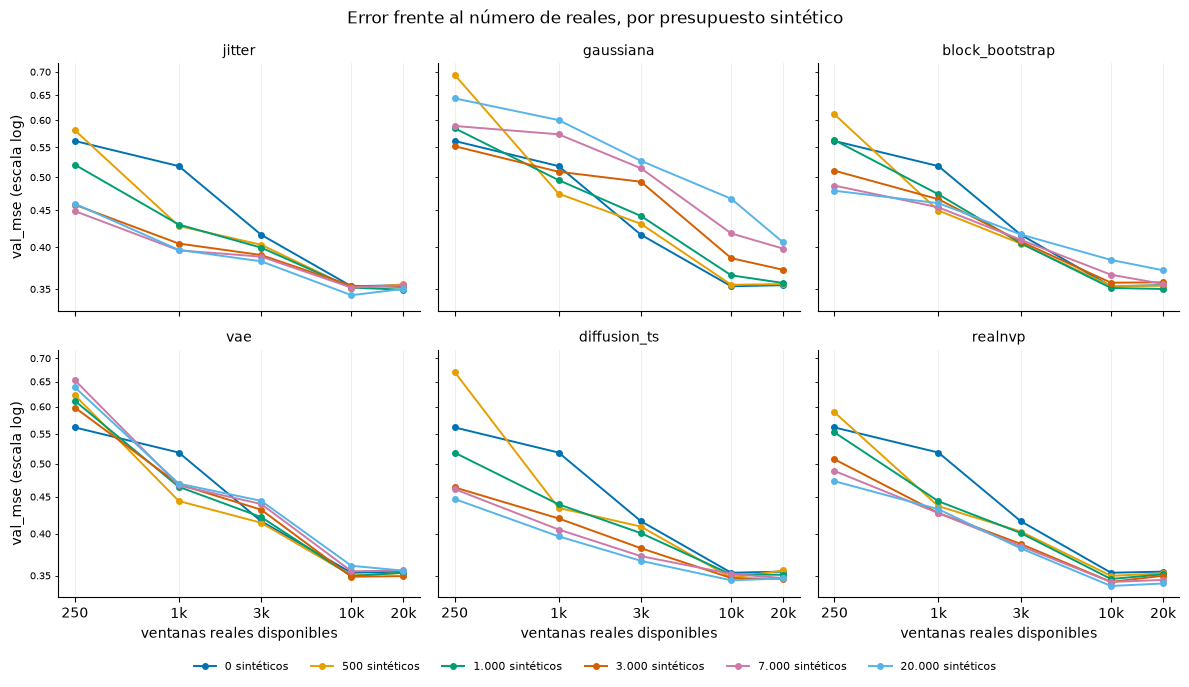

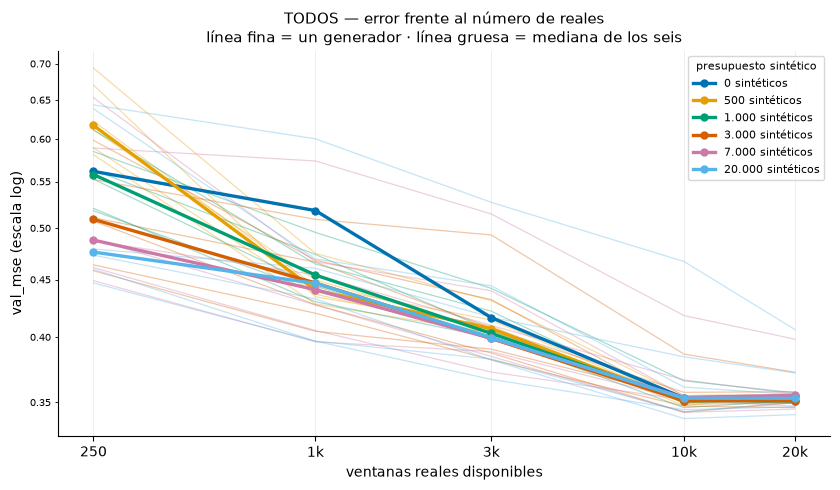

In [12]:
fig27 = plot_curvas_error_por_generador(df_curvas, N_REALES_CURVAS, N_SINTETICOS,
                                        GENERADORES, metrica="val_mse")
fig27.savefig(cfg.fig_dir / "27_curvas_error_por_generador.png",
              dpi=120, bbox_inches="tight")

fig28 = plot_curvas_error_todos(df_curvas, N_REALES_CURVAS, N_SINTETICOS,
                                GENERADORES, metrica="val_mse")
fig28.savefig(cfg.fig_dir / "28_curvas_error_todos.png", dpi=120, bbox_inches="tight")


In [13]:
# Las tres tablas que sostienen la lectura de abajo. Se calculan del CSV, no
# se copian a mano: si la malla cambia, el texto se queda obsoleto a la vista.

# (1) Convergencia: cuánto separa a la mejor de la peor celda en cada régimen.
conv = df_curvas.groupby("n_real")["val_mse"].agg(["min", "max"])
conv["cociente"] = conv["max"] / conv["min"]
print("Dispersión entre celdas — cuánto importa elegir bien el generador:")
display(conv.round(3))

# (2) Veredictos pareados por semilla, misma regla que §2.1.b (|t| >= 2,5).
#     En val_mse menos es mejor, de ahí mas_es_mejor=False.
par_curvas = delta_pareado(df_curvas, metrica="val_mse",
                           presupuesto="n_synth", mas_es_mejor=False)
print("\nVeredictos por régimen de escasez:")
display(pd.crosstab(par_curvas.n_real, par_curvas.veredicto))


# El CSV de conclusiones usa el R² del test intocado. Mostrar ambos evita
# interpretar una diferencia de selección (val_mse) como una contradicción.
par_curvas_test = delta_pareado(df_curvas, metrica="test_r2",
                                presupuesto="n_synth", mas_es_mejor=True)
print("\nVeredictos paralelos en R² del test real:")
display(pd.crosstab(par_curvas_test.n_real, par_curvas_test.veredicto))

# (3) ¿Hay óptimo intermedio? Pendiente de val_mse frente a log(n_synth).
#     Positiva = más sintéticos, más error. Si la relación fuese en U, el signo
#     cambiaría dentro de una misma fila; que no lo haga es la refutación de H2.
pend = {}
for g in GENERADORES:
    pend[g] = {n: np.polyfit(np.log(s.index), s.values, 1)[0]
               for n in N_REALES_CURVAS
               for s in [df_curvas[(df_curvas.generador == g) & (df_curvas.n_real == n) &
                                   (df_curvas.n_synth > 0)]
                         .groupby("n_synth")["val_mse"].mean()]}
print("\nPendiente de val_mse vs log(n_synth) — el signo lo fija el generador:")
display(pd.DataFrame(pend).T.loc[GENERADORES].round(3))

# El detalle completo, por si hace falta mirar una celda concreta.
print("\nval_mse medio (filas: generador × presupuesto sintético | columnas: reales):")
display(df_curvas.pivot_table(index=["generador", "n_synth"], columns="n_real",
                              values="val_mse", aggfunc="mean").round(3))

Dispersión entre celdas — cuánto importa elegir bien el generador:


,min,max,cociente
n_real,,,
250,0.377,0.798,2.119
1000,0.359,0.670,1.865
3000,0.349,0.568,1.630
10000,0.323,0.513,1.588
20000,0.325,0.411,1.265



Veredictos por régimen de escasez:


veredicto,empeora,mejora,no concluyente
n_real,,,
250,0,3,27
1000,0,0,30
3000,2,16,12
10000,6,5,19
20000,3,2,25



Veredictos paralelos en R² del test real:


veredicto,empeora,mejora,no concluyente
n_real,,,
250,0,5,25
1000,0,1,29
3000,5,11,14
10000,9,4,17
20000,10,0,20



Pendiente de val_mse vs log(n_synth) — el signo lo fija el generador:


,250,1000,3000,10000,20000
jitter,-0.033,-0.010,-0.006,-0.002,-0.000
gaussiana,-0.009,0.035,0.028,0.030,0.015
block_bootstrap,-0.036,-0.000,0.003,0.008,0.005
vae,0.008,0.005,0.008,0.003,0.001
diffusion_ts,-0.052,-0.012,-0.012,-0.001,-0.002
realnvp,-0.032,-0.003,-0.006,-0.003,-0.003



val_mse medio (filas: generador × presupuesto sintético | columnas: reales):


n_real                   250    1000   3000   10000  20000
generador       n_synth                                   
block_bootstrap 500      0.611  0.450  0.405  0.354  0.354
                1000     0.563  0.474  0.405  0.351  0.350
                3000     0.511  0.466  0.407  0.357  0.358
                7000     0.487  0.454  0.410  0.366  0.356
                20000    0.479  0.461  0.417  0.384  0.372
diffusion_ts    500      0.670  0.434  0.409  0.348  0.356
                1000     0.518  0.439  0.401  0.351  0.351
                3000     0.464  0.420  0.382  0.347  0.346
                7000     0.461  0.405  0.372  0.352  0.347
                20000    0.447  0.397  0.367  0.345  0.347
gaussiana       500      0.694  0.475  0.431  0.355  0.356
                1000     0.585  0.496  0.442  0.366  0.357
                3000     0.552  0.509  0.493  0.386  0.372
                7000     0.589  0.574  0.515  0.418  0.398
                20000    0.643  0.600  0.527  0.467  0.406
jitter          500      0.581  0.428  0.403  0.351  0.355
                1000     0.521  0.430  0.400  0.352  0.349
                3000     0.458  0.405  0.390  0.354  0.352
                7000     0.449  0.396  0.388  0.352  0.354
                20000    0.460  0.397  0.382  0.343  0.350
ninguno         0        0.562  0.518  0.416  0.353  0.354
realnvp         500      0.589  0.437  0.403  0.350  0.352
                1000     0.553  0.444  0.401  0.346  0.351
                3000     0.507  0.427  0.387  0.343  0.350
                7000     0.489  0.427  0.384  0.343  0.345
                20000    0.473  0.433  0.382  0.339  0.341
vae             500      0.622  0.444  0.414  0.350  0.353
                1000     0.611  0.465  0.422  0.349  0.353
                3000     0.598  0.468  0.432  0.349  0.349
                7000     0.653  0.467  0.440  0.355  0.356
                20000    0.638  0.469  0.444  0.361  0.356

#### Lectura

La malla son **465 celdas**: 5 niveles de reales × 5 presupuestos sintéticos × 6
generadores × 3 semillas, más 15 referencias de solo-real. WGAN-GP ya no forma parte de
la matriz activa; Diffusion-TS R61 ocupa exactamente sus 75 celdas.

**1 · El generador importa menos a medida que crece el dato real.** El cociente entre el
mejor y el peor `val_mse` cae de **2,12× con 250 reales a 1,26× con 20.000**. La elección
es crítica en escasez y casi marginal al final de la curva.

**2 · Diffusion-TS ayuda sin introducir una zona sistemáticamente tóxica.** Sobre
`val_mse` obtiene **8 mejoras, 0 empeoramientos y 17 celdas no concluyentes**. En el R² del
test real son **9 mejoras, 1 empeoramiento y 15 no concluyentes**; la única pérdida es
pequeña y aislada (20.000 reales + 500 sintéticos, ΔR² −0,0037). En N=3.000 la mejora
crece de +0,002 a +0,061 R² al pasar de 500 a 20.000 sintéticos.

**3 · El efecto se concentra entre escasez severa y el régimen medio.** Con 250 reales,
Diffusion-TS mejora el test desde 1.000 sintéticos; con 1.000 reales los cinco estimadores
son positivos pero cuatro quedan bajo el ruido entre semillas; con 3.000 hay tres mejoras
claras desde 3.000 sintéticos. A partir de 10.000 reales el margen práctico se comprime a
milésimas.

**4 · No aparece un óptimo interior estable.** La pendiente de `val_mse` frente a
`log(n_synth)` es negativa para Diffusion-TS en los cinco regímenes, igual que para jitter
y RealNVP. Eso apoya usar más sintético dentro del rango ensayado cuando hay pocos reales,
pero no autoriza extrapolar más allá de 20.000 ventanas.

## 3 · Análisis crítico y decisión

Se han ejecutado dos diseños con la `gru_l` congelada: **333 celdas** de ratios finos y
**465 celdas** de presupuestos absolutos. En ambos, cada semilla conserva el mismo
submuestreo real al comparar solo-real contra real+sintético. Diffusion-TS se ajustó 15
veces, una por pareja `(N_real, semilla)`, y la muestra DDIM máxima se reutilizó por
prefijos idénticos para cubrir presupuestos solapados sin alterar una sola observación.

### Resultado específico de Diffusion-TS R61

| Evidencia | Resultado | Lectura |
|---|---:|---|
| TSTR | R² 0,4773; 94,72 % de TRTR | empata con RealNVP y supera ampliamente al WGAN histórico |
| Ratios finos | **7 mejora / 0 empeora / 11 NC** | las 6 dosis mejoran con N=3.000 |
| Curvas, test R² | **9 mejora / 1 empeora / 15 NC** | fuerte con pocos/mid datos; marginal con 10k–20k |
| Frente a WGAN | +0,168 R² medio en ratios; +0,128 en curvas | gana 52/54 y 69/75 comparaciones pareadas |
| Frente a RealNVP | −0,010 en ratios; +0,0003 en curvas | empate global |
| Frente a jitter | −0,0215 en ratios; −0,0009 en curvas | el baseline simple sigue siendo muy competitivo |

En N=3.000, el resultado más estable, Diffusion-TS mejora **todos** los ratios: desde
ΔR² +0,0136 con 0,25× hasta +0,0629 con 5×. En N=1.000 las seis medias también son
positivas (+0,095 a +0,158), pero la gran dispersión del solo-real impide declararlas
concluyentes con tres semillas. Con N=250 el efecto es no monótono y solo 5× concluye
como mejora (+0,0765).

### Contraste de hipótesis

**H1 · "El sintético ayuda sobre todo con pocos reales" → MATIZADA.** El potencial bruto
es mayor con 250–1.000 reales, pero también lo es el ruido de optimización. La evidencia más
limpia aparece con 3.000; a partir de 10.000 la ganancia se reduce a milésimas.

**H2 · "Existe un óptimo intermedio" → NO OBSERVADO EN EL RANGO.** Para N=3.000 la
ganancia de Diffusion crece de forma sostenida entre 0,25× y 5×, y en la malla absoluta
hasta 20.000 sintéticos. La irregularidad con N=250 impide convertirlo en una ley general.

**H3 · "La gaussiana será difícil de batir" → REFUTADA.** En ratios acumula 0 mejoras y
3 empeoramientos; su falta de colas y clustering se transforma en sesgo downstream.

**H4 · "Las redes generativas pierden donde hacen falta" → REFUTADA COMO CLASE.** El VAE
no aporta mejoras en ratios, pero Diffusion-TS y RealNVP son los dos modelos aprendidos más
fuertes. El fallo era del WGAN-GP concreto, no de que el generador fuese neuronal.

**H5 · "Jitter es difícil de batir" → CONFIRMADA.** Promedia +0,059 R² en ratios, por
delante de RealNVP (+0,0475) y Diffusion (+0,0375). En curvas los tres empatan en la práctica
(+0,0508, +0,0496 y +0,0499 respectivamente).

### La auditoría predice el descarte, no el ganador absoluto

Al cruzar los seis generadores activos con la ganancia de ratios, el discriminative AUC es
el mejor predictor global (Spearman **−0,94**), seguido de W1 por columna (−0,83), error
de correlación de rangos (−0,77) y TSTR (+0,71). El TSTR ordena Diffusion primero, pero la
malla de ratios la coloca tercera. La conclusión metodológica es más sobria: la auditoría
detecta bien generadores peligrosos; entre candidatos fuertes hace falta la malla.

### Decisión definitiva

> **Sí merece la pena sustituir WGAN-GP por Diffusion-TS R61 en el pipeline activo.** La
> mejora es grande y consistente en TSTR y en ambas mallas. **No merece convertirse en el
> único generador por defecto:** globalmente empata con RealNVP y jitter, cuesta más que el
> baseline y conserva peor la escala y el clustering que RealNVP. Su caso de uso más claro
> es la ampliación con aproximadamente 3.000 ventanas reales y presupuestos sintéticos de
> 1×–6,7×; con 10.000–20.000 reales el beneficio práctico casi desaparece.

### Limitaciones

1. Solo hay tres semillas; en N=250 y N=1.000 muchos efectos quedan bajo el ruido.
2. Se ha probado una configuración de Diffusion-TS, un split temporal y un target.
3. La reutilización por prefijos es exacta y auditable, pero comparte el mismo ajuste del
   generador entre presupuestos: los tests downstream sí son independientes por semilla.
4. R61 garantiza igualdad de información con los demás modelos; R81 queda excluido porque
   habría dado a Diffusion veinte retornos adicionales que ningún rival ve.

## 4 · Persistencia

Los CSV de las dos mallas —la de ratios y la de curvas— son el artefacto que alimenta
la presentación. Se guardan en `data/processed/` junto al resto, y se versionan.

In [14]:
resumen.to_csv(cfg.out_dir / f"malla_{MALLA.lower()}_resumen.csv", index=False)
delta.to_csv(cfg.out_dir / f"malla_{MALLA.lower()}_delta.csv", index=False)
resumir(df_curvas).to_csv(cfg.out_dir / "malla_curvas_resumen.csv", index=False)
print("Guardado:")
for p in sorted(cfg.out_dir.glob("malla_*.csv")):
    print(f"  {p.name}  ({p.stat().st_size/1024:.0f} KB)")


Guardado:
  malla_curvas.csv  (58 KB)
  malla_curvas_delta_pareado.csv  (17 KB)
  malla_curvas_resumen.csv  (14 KB)
  malla_ratios_finos.csv  (40 KB)
  malla_ratios_finos_delta.csv  (13 KB)
  malla_ratios_finos_delta_pareado.csv  (12 KB)
  malla_ratios_finos_resumen.csv  (9 KB)
